In [1]:
!rm -rf /kaggle/working/hack-mfti
!git config --global credential.helper store
!echo GITHUB_TOKEN > ~/.git-credentials
!git clone -b case/sber --single-branch https://github.com/be1pheg0r/hack-mfti.git
!git -C /kaggle/working/hack-mfti log -1 --oneline

import sys
sys.path.insert(0, "/kaggle/working/hack-mfti")

!cd hack-mfti && pip install -e . -q

Cloning into 'hack-mfti'...
remote: Enumerating objects: 556, done.
remote: Counting objects: 100% (391/391), done.
remote: Compressing objects: 100% (224/224), done.
remote: Total 556 (delta 220), reused 324 (delta 160), pack-reused 165 (from 1)
Receiving objects: 100% (556/556), 8.56 MiB | 19.70 MiB/s, done.
Resolving deltas: 100% (295/295), done.
a537b87 (HEAD -> case/sber, origin/case/sber) [sber/hotfix] Добавил инит, чтобы пакет читался
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.7 MB/s eta 0:00:0000:0100:01
  Building editable for hack-mfti-sber (pyproject.toml) ... done


In [3]:
from common.paths import get_data_raw_dpath, get_data_bench_dpath
from common.logger import JUPYTER_LOGGER as logger

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, f1_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

In [5]:
features_fpath = get_data_raw_dpath() / "features_with_judge_scores.csv"
test_fpath = get_data_bench_dpath() / "knowledge_bench_public.csv"
train_df = pd.read_csv(features_fpath)
train_df = train_df.dropna(subset=["correct_answer", "model_answer", "is_hallucination"]).reset_index(drop=True)
train_df["is_hallucination"] = train_df["is_hallucination"].astype(int)

val_df = pd.read_csv(test_fpath)
val_df = val_df.dropna(subset=["correct_answer", "model_answer", "is_hallucination"]).reset_index(drop=True)
val_df["is_hallucination"] = val_df["is_hallucination"].astype(int)

logger.info(train_df.shape)
logger.info(val_df.shape)
train_df.head(2)

2026-04-04 12:00:17,517 - jupyter-notebooks - INFO - [JUPYTER 📓] (1391, 1622)
2026-04-04 12:00:17,520 - jupyter-notebooks - INFO - [JUPYTER 📓] (1044, 5)


,sample_id,query,correct_answer,model_answer,temperature,hallucination_score,is_hallucination,feature_0,feature_1,feature_2,...,feature_1605,feature_1606,feature_1607,feature_1608,feature_1609,feature_1610,feature_1611,feature_1612,judge_prompt,judge_score
0,0,"ЭТОГО православного святого иногда называют ""м...",Федор УШАКОВ,Святого Николая Чудотворца иногда называют «мо...,1.049065,41.666667,1,-2.184582,-16.949598,-0.000303,...,0.028273,0.019163,0.029646,0.015739,0.073697,0.044748,0.5,0.0,"\nТы — судья, оценивающий точность ответа моде...",True
1,1,"Где родился создатель музыки к фильму ""Крадено...",Каламата,Создателем музыки к фильму «Краденое небо» явл...,1.049065,37.500000,1,-2.548452,-17.273001,-0.000017,...,0.027378,0.014426,0.033654,0.019120,0.075012,0.035969,0.5,0.0,"\nТы — судья, оценивающий точность ответа моде...",True


In [22]:
from sklearn.utils import resample

pos = train_df[train_df["is_hallucination"] == 1]
neg = train_df[train_df["is_hallucination"] == 0]

# undersample majority
pos_down = resample(pos, n_samples=len(neg), random_state=42)
train_df = pd.concat([pos_down, neg]).sample(frac=1, random_state=42)
train_df["is_hallucination"].value_counts()

is_hallucination
1    300
0    300
Name: count, dtype: int64

In [39]:
model_name = "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, device_map="auto")
model.eval()

def predict_nli(premise: str, hypothesis: str) -> dict:
    inputs = tokenizer(premise, hypothesis, truncation=True, return_tensors="pt").to("cuda")
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.softmax(logits[0], dim=-1).tolist()
    labels = ["entailment", "neutral", "contradiction"]
    return dict(zip(labels, probs))

# hallucination = contradiction или neutral (не entailment)
# False = нет галлюцинации, True = галлюцинация
def is_hallucination(premise: str, hypothesis: str, threshold: float = 0.5) -> bool:
    scores = predict_nli(premise, hypothesis)
    return scores["entailment"] < threshold

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
MODEL_NAME = "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7"
MAX_LEN    = 512
BATCH_SIZE = 8
EPOCHS     = 5
LR         = 3e-5 / 2
SEED       = 42
DTYPE = torch.float32

torch.manual_seed(SEED)
np.random.seed(SEED)

In [25]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup


class HallucinationDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.df        = df
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tokenizer(
            row["correct_answer"],
            row["model_answer"],
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        label = torch.tensor(row["is_hallucination"], dtype=torch.long)
        return {k: v.squeeze(0) for k, v in enc.items()}, label

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



tokenizer    = AutoTokenizer.from_pretrained(MODEL_NAME)
train_loader = DataLoader(HallucinationDataset(train_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(HallucinationDataset(val_df,   tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [29]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True,
    dtype=DTYPE,
).to(device)

in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 2).to(device=device, dtype=DTYPE)

with torch.no_grad():
    nn.init.xavier_uniform_(model.classifier.weight)
    nn.init.zeros_(model.classifier.bias)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * len(train_loader) * EPOCHS),
    num_training_steps=len(train_loader) * EPOCHS,
)

class_counts = train_df["is_hallucination"].value_counts().sort_index().values
weights = 1.0 / class_counts
weights = weights / weights.sum()
logger.info(weights)

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(weights, device=device, dtype=DTYPE)
)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7
Key                             | Status     |                                                                                     
--------------------------------+------------+-------------------------------------------------------------------------------------
deberta.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.bias                 | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          
classifier.weight               | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
2026-04-04 14

In [30]:
model.eval()
batch, labels = next(iter(train_loader))
batch = {k: v.to(device) for k, v in batch.items()}

with torch.no_grad(), torch.autocast(device_type="cuda", dtype=DTYPE):
    print(model(**batch).logits[:3])

tensor([[-1.0624, -0.5255],
        [-1.2763, -0.2922],
        [-0.1917, -0.2904]], device='cuda:0')


In [31]:
def evaluate(model, loader):
    model.eval()

    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for batch, labels in tqdm(loader):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = labels.to(device)

            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits = model(**batch).logits

            probs = torch.softmax(logits.float(), dim=-1)[:, 1].cpu().numpy()
            preds = logits.argmax(dim=-1).cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    y_true  = np.array(all_labels)
    y_pred  = np.array(all_preds)
    y_probs = np.array(all_probs)

    if np.any(~np.isfinite(y_probs)):
        y_probs = np.nan_to_num(y_probs, nan=0.5)

    sw = np.where(y_true == 1,
                  (1 - y_true.mean()) / y_true.mean(),
                  1.0)

    ap = average_precision_score(y_true, y_probs, sample_weight=sw)
    f1 = f1_score(y_true, y_pred, pos_label=1)

    return ap, f1, y_true, y_pred

In [32]:
best_ap = 0.0
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for batch, labels in tqdm(train_loader, desc=f"Epoch {epoch}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)
    
        optimizer.zero_grad(set_to_none=True)
    
        with torch.autocast(device_type="cuda", dtype=DTYPE):
            logits = model(**batch).logits
            loss = criterion(logits, labels)
    
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    ap, f1, _, _ = evaluate(model, val_loader)
    logger.info(f"Epoch {epoch} | loss={total_loss / len(train_loader):.4f} | weighted AP={ap:.4f} | F1={f1:.4f}")
    if ap > best_ap:
        best_ap = ap
        torch.save(model.state_dict(), "best_hallucination_model.pt")
        logger.info("  → saved")

Epoch 1:   0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

2026-04-04 14:53:05,591 - jupyter-notebooks - INFO - [JUPYTER 📓] Epoch 1 | loss=0.6054 | weighted AP=0.9290 | F1=0.7478
2026-04-04 14:53:07,424 - jupyter-notebooks - INFO - [JUPYTER 📓]   → saved


Epoch 2:   0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

...

  0%|          | 0/131 [00:00<?, ?it/s]

2026-04-04 15:01:39,683 - jupyter-notebooks - INFO - [JUPYTER 📓] Epoch 4 | loss=0.0310 | weighted AP=0.9444 | F1=0.8965


Epoch 5:   0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

2026-04-04 15:04:09,273 - jupyter-notebooks - INFO - [JUPYTER 📓] Epoch 5 | loss=0.0259 | weighted AP=0.9430 | F1=0.8914


In [33]:
from huggingface_hub import login
login(token=HUGGINGFACE_TOKEN)

repo_name = "be1pheg0r/hack-mfti-sbercase"
model.load_state_dict(torch.load("best_hallucination_model.pt"))
model.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)

README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/be1pheg0r/hack-mfti-sbercase/commit/b26f272c9a1e954ae8221ac701783d09c6ced9c3', commit_message='Upload tokenizer', commit_description='', oid='b26f272c9a1e954ae8221ac701783d09c6ced9c3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/be1pheg0r/hack-mfti-sbercase', endpoint='https://huggingface.co', repo_type='model', repo_id='be1pheg0r/hack-mfti-sbercase'), pr_revision=None, pr_num=None)

In [34]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(repo_name)

model = AutoModelForSequenceClassification.from_pretrained(
    repo_name,
    torch_dtype=torch.bfloat16,
).to(device)

config.json:   0%|          | 0.00/922 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [36]:
!cd hack-mfti && python scripts/evaluate.py --input-csv data/bench/knowledge_bench_public.csv --compute-dtype bfloat16

2026-04-04 15:12:39,031 - sber-evaluation - INFO - [SBER-EVALUATION 📊] Читаю benchmark: data/bench/knowledge_bench_public.csv
Scoring benchmark:   0%|                                | 0/131 [00:00<?, ?it/s]2026-04-04 15:12:39,053 - sber-nli-inference - INFO - [SBER-NLI-INFERENCE 🤖] Скачиваю модель be1pheg0r/hack-mfti-sbercase в /kaggle/working/hack-mfti/model/hack-mfti-sbercase
2026-04-04 15:12:40,074 - sber-nli-inference - INFO - [SBER-NLI-INFERENCE 🤖] Модель скачана: /kaggle/working/hack-mfti/model/hack-mfti-sbercase
2026-04-04 15:12:40,074 - sber-nli-inference - INFO - [SBER-NLI-INFERENCE 🤖] HFNLIClf snapshot готов: /kaggle/working/hack-mfti/model/hack-mfti-sbercase
2026-04-04 15:12:40,151 - sber-nli-inference - INFO - [SBER-NLI-INFERENCE 🤖] HFNLIClf: GPU=2, dtype=torch.bfloat16, device=cuda:0
Scoring benchmark: 100%|██████████████████████| 131/131 [02:01<00:00,  1.07it/s]
2026-04-04 15:14:41,146 - sber-evaluation - INFO - [SBER-EVALUATION 📊] Считаю сводные метрики скоринга
2026-04-

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from copy import deepcopy

FRACTIONS = [0.10, 0.25, 0.50, 0.75, 1.00]
SEEDS = [42, 123, 456]

results = {f: [] for f in FRACTIONS}

def make_model():
    m = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        ignore_mismatched_sizes=True,
        dtype=DTYPE,
    ).to(device)
    in_features = m.classifier.in_features
    m.classifier = nn.Linear(in_features, 2).to(device=device, dtype=DTYPE)
    with torch.no_grad():
        nn.init.xavier_uniform_(m.classifier.weight)
        nn.init.zeros_(m.classifier.bias)
    return m

In [13]:
from tqdm.auto import tqdm

full_train_indices = np.arange(len(train_df))
full_dataset = HallucinationDataset(train_df, tokenizer, MAX_LEN)

for frac in (pbar_frac := tqdm(FRACTIONS, desc="Fractions", unit="frac")):
    pbar_frac.set_postfix(frac=f"{frac:.0%}")
    n = max(int(len(full_train_indices) * frac), 1)
    ap_runs = []

    for seed in (pbar_seed := tqdm(SEEDS, desc=f"  Seeds [{frac:.0%}]", leave=False)):
        pbar_seed.set_postfix(seed=seed)
        rng = np.random.default_rng(seed)
        idx = rng.choice(full_train_indices, size=n, replace=False)
        subset = Subset(full_dataset, idx)
        loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

        model = make_model()
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(0.1 * len(loader) * EPOCHS),
            num_training_steps=len(loader) * EPOCHS,
        )
        criterion = nn.CrossEntropyLoss(
            weight=torch.tensor([3.0, 1.0], device=device, dtype=DTYPE)
        )

        for epoch in (pbar_epoch := tqdm(range(1, EPOCHS + 1), desc=f"    Epochs", leave=False)):
            pbar_epoch.set_postfix(epoch=epoch)
            model.train()
            for batch, labels in tqdm(loader, desc=f"      Batches", leave=False):
                batch = {k: v.to(device) for k, v in batch.items()}
                labels = labels.to(device)
                optimizer.zero_grad(set_to_none=True)
                with torch.autocast(device_type="cuda", dtype=DTYPE):
                    logits = model(**batch).logits
                    loss = criterion(logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

        ap, f1, _, _ = evaluate(model, val_loader)
        ap_runs.append(ap)
        pbar_seed.set_postfix(seed=seed, AP=f"{ap:.4f}", F1=f"{f1:.4f}")
        logger.info(f"frac={frac:.0%} | seed={seed} | AP={ap:.4f} | F1={f1:.4f}")

        del model
        torch.cuda.empty_cache()

    results[frac] = ap_runs
    mean_ap = np.mean(ap_runs)
    pbar_frac.set_postfix(frac=f"{frac:.0%}", mean_AP=f"{mean_ap:.4f}")
    logger.info(f"frac={frac:.0%} | mean AP={mean_ap:.4f} ± {np.std(ap_runs):.4f}")

Fractions:   0%|          | 0/5 [00:00<?, ?frac/s]

  Seeds [10%]:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7
Key                             | Status     |                                                                                     
--------------------------------+------------+-------------------------------------------------------------------------------------
deberta.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.bias                 | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          
classifier.weight               | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


    Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

...

      Batches:   0%|          | 0/174 [00:00<?, ?it/s]

      Batches:   0%|          | 0/174 [00:00<?, ?it/s]

      Batches:   0%|          | 0/174 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

2026-04-04 14:40:11,892 - jupyter-notebooks - INFO - [JUPYTER 📓] frac=100% | seed=456 | AP=0.9173 | F1=0.8639
2026-04-04 14:40:11,948 - jupyter-notebooks - INFO - [JUPYTER 📓] frac=100% | mean AP=0.9122 ± 0.0181


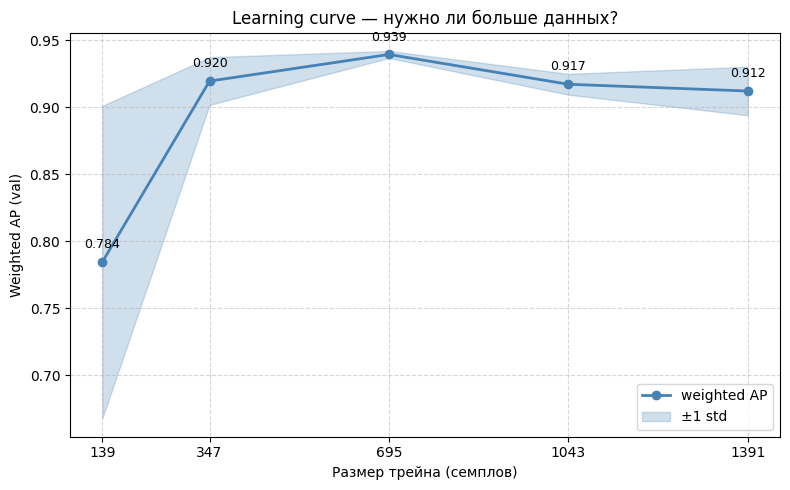

In [14]:
sizes   = [int(len(train_df) * f) for f in FRACTIONS]
means   = [np.mean(results[f]) for f in FRACTIONS]
stds    = [np.std(results[f])  for f in FRACTIONS]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, means, marker='o', linewidth=2, color='steelblue', label='weighted AP')
ax.fill_between(sizes,
                np.array(means) - np.array(stds),
                np.array(means) + np.array(stds),
                alpha=0.25, color='steelblue', label='±1 std')

for x, y, s in zip(sizes, means, stds):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=9)

ax.set_xlabel("Размер трейна (семплов)")
ax.set_ylabel("Weighted AP (val)")
ax.set_title("Learning curve — нужно ли больше данных?")
ax.set_xticks(sizes)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150)
plt.show()

In [17]:
for frac in FRACTIONS:
    n = max(int(len(train_df) * frac), 1)
    for seed in SEEDS:
        rng = np.random.default_rng(seed)
        idx = rng.choice(np.arange(len(train_df)), size=n, replace=False)
        subset_labels = train_df.iloc[idx]["is_hallucination"]  # или как у тебя колонка называется
        pos_rate = subset_labels.mean()
        print(f"frac={frac:.0%} seed={seed} | pos_rate={pos_rate:.3f} | n={n}")

frac=10% seed=42 | pos_rate=0.784 | n=139
frac=10% seed=123 | pos_rate=0.842 | n=139
frac=10% seed=456 | pos_rate=0.791 | n=139
frac=25% seed=42 | pos_rate=0.769 | n=347
frac=25% seed=123 | pos_rate=0.804 | n=347
frac=25% seed=456 | pos_rate=0.813 | n=347
frac=50% seed=42 | pos_rate=0.797 | n=695
frac=50% seed=123 | pos_rate=0.776 | n=695
frac=50% seed=456 | pos_rate=0.777 | n=695
frac=75% seed=42 | pos_rate=0.779 | n=1043
frac=75% seed=123 | pos_rate=0.802 | n=1043
frac=75% seed=456 | pos_rate=0.783 | n=1043
frac=100% seed=42 | pos_rate=0.784 | n=1391
frac=100% seed=123 | pos_rate=0.784 | n=1391
frac=100% seed=456 | pos_rate=0.784 | n=1391
